In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))  
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from utils.get_google_drive_data import load_csv_from_drive
from utils.google_drive_client import get_drive_client
from utils.utils import get_data_split
from utils.features import rate_table, rate_plot

In [2]:
service = get_drive_client()
df = load_csv_from_drive(service) 

In [3]:
X_train, X_test, y_train, y_test = get_data_split(df)
train_df = pd.concat([X_train, y_train], axis=1)

In [4]:
train_df.head()

,project id,name,url,category,subcategory,location,goal,pledged,funded percentage,backers,funded date,levels,reward levels,updates,comments,duration,target
40825,1914040019,Summit to Sea,http://www.kickstarter.com/projects/lahoffman/...,Art,Illustration,"Stevensville, Mt",8500.0,2034.0,0.239294,37,"Thu, 01 Mar 2012 06:59:00 -0000",10,"$10,$25,$35,$45,$95,$150,$200,$250,$325,$450",5,3,42.59,False
16576,783122916,Tamara Saari Dance,http://www.kickstarter.com/projects/1117453527...,Dance,Dance,"Lower East Side, NY",2000.0,2017.0,1.008555,36,"Thu, 01 Mar 2012 16:22:00 -0000",6,"$10,$25,$50,$100,$150,$250",6,0,31.60,True
5060,240036276,Four Clowns 2011 National Tour,http://www.kickstarter.com/projects/506558983/...,Theater,Theater,"Los Angeles, CA",5000.0,5210.0,1.042000,48,"Tue, 05 Jul 2011 03:59:00 -0000",7,"$10,$25,$50,$100,$200,$500,$1,000",3,0,40.99,True
47,2353033,&quot;Chased Resignation&quot;,http://www.kickstarter.com/projects/chasedresi...,Film & Video,Film &amp; Video,"Arcadia, CA",20000.0,0.0,0.000000,0,"Tue, 26 Jul 2011 04:00:00 -0000",3,"$20,$100,$1,000",0,0,63.23,False
6455,303755237,People Get Ready: The Parchman Hour is Coming!,http://www.kickstarter.com/projects/90005631/p...,Theater,Theater,"Jackson, MS",7000.0,7100.0,1.014286,104,"Wed, 25 May 2011 02:11:06 -0000",6,"$10,$30,$60,$100,$250,$500",36,11,30.00,True


In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29375 entries, 40825 to 2247
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   project id         29375 non-null  int64  
 1   name               29375 non-null  object 
 2   url                29375 non-null  object 
 3   category           29375 non-null  object 
 4   subcategory        29375 non-null  object 
 5   location           28472 non-null  object 
 6   goal               29375 non-null  float64
 7   pledged            29375 non-null  float64
 8   funded percentage  29375 non-null  float64
 9   backers            29375 non-null  int64  
 10  funded date        29375 non-null  object 
 11  levels             29375 non-null  int64  
 12  reward levels      29335 non-null  object 
 13  updates            29375 non-null  int64  
 14  comments           29375 non-null  int64  
 15  duration           29375 non-null  float64
 16  target             29375

In [6]:
info = pd.DataFrame({
    "dtype": X_train.dtypes.astype(str),
    "non-null": X_train.notna().sum(),
    "null": X_train.isna().sum(),
    "null %": (X_train.isna().mean() * 100).round(2),
    "unique": X_train.nunique(),
    "example": X_train.iloc[0].astype(str).str.slice(0, 40),
})
info

,dtype,non-null,null,null %,unique,example
project id,int64,29375,0,0.00,29321,1914040019
name,object,29375,0,0.00,29288,Summit to Sea
url,object,29375,0,0.00,29321,http://www.kickstarter.com/projects/laho
category,object,29375,0,0.00,14,Art
subcategory,object,29375,0,0.00,51,Illustration
location,object,28472,903,3.07,3682,"Stevensville, Mt"
goal,float64,29375,0,0.00,1340,8500.0
pledged,float64,29375,0,0.00,8740,2034.0
funded percentage,float64,29375,0,0.00,15153,0.239294118
backers,int64,29375,0,0.00,795,37


In [7]:
train_df.describe()

,project id,goal,pledged,funded percentage,backers,levels,updates,comments,duration
count,2.937500e+04,2.937500e+04,2.937500e+04,29375.000000,29375.000000,29375.000000,29375.000000,29375.000000,29375.000000
mean,1.077376e+09,9.454898e+03,5.292068e+03,1.556393,73.304102,7.948357,4.308289,8.625260,40.174240
std,6.217019e+08,3.986794e+04,6.906815e+04,60.919587,812.774143,4.133787,6.550769,184.864453,17.775351
min,3.940900e+04,1.000000e-02,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,5.394866e+08,1.600000e+03,2.200000e+02,0.051000,5.000000,5.000000,0.000000,0.000000,30.000000
50%,1.071316e+09,4.000000e+03,1.447000e+03,1.005200,24.000000,7.000000,2.000000,1.000000,32.040000
75%,1.620217e+09,8.500000e+03,4.354500e+03,1.130879,61.000000,10.000000,6.000000,3.000000,48.940000
max,2.147460e+09,3.500000e+06,1.026684e+07,10000.000000,87142.000000,74.000000,142.000000,19311.000000,91.960000


# Exploring the Goal Feature
We can see the dataset has a big range. In Figure 1 we can see most goals seem to be concentrated at relatively small dollar amounts. Figure 2 makes this even more clear as we can see the distrubution is centered from 3000-10000 dollars goals. Through these figures we can clearly see we we have a long-tailed, right-skewed distribution.

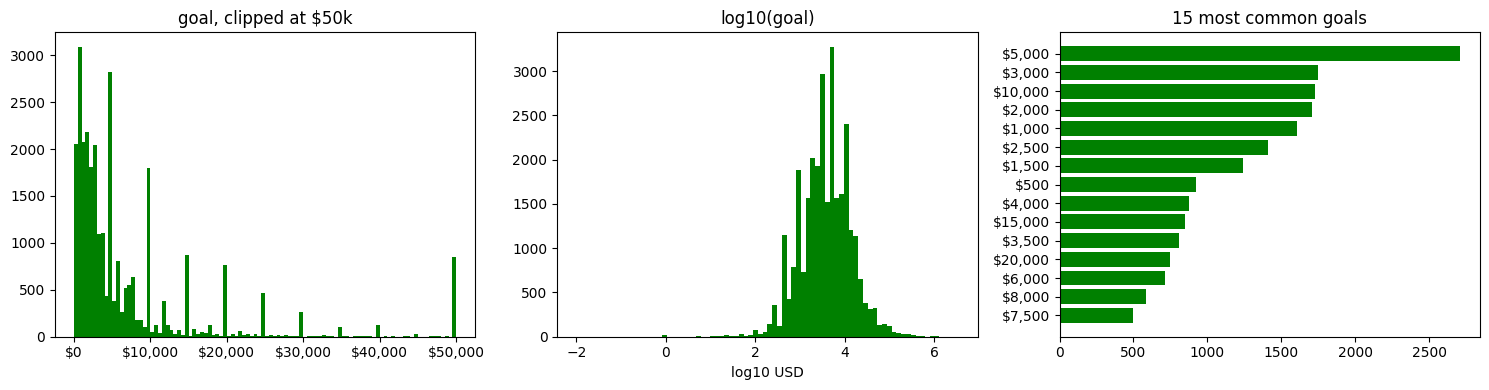

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(X_train["goal"].clip(upper=50_000), bins=100, color='green')
axes[0].set_title("goal, clipped at $50k"); axes[0].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[1].hist(np.log10(X_train["goal"]), bins=80, color='green')
axes[1].set_title("log10(goal)"); axes[1].set_xlabel("log10 USD")
top = X_train["goal"].value_counts().head(15)
axes[2].barh([f"${int(v):,}" for v in top.index][::-1], top.values[::-1], color='green')
axes[2].set_title("15 most common goals")
plt.tight_layout()

# Success rate by Goal
As we can see success rate is higher for lower goal amounts, however it get progressively lower as the goal amount increases.

,n,rate,ci_lo,ci_hi,vs_base
goal,,,,,
<$500,2058,0.719,0.699,0.738,0.172
$500–1k,3089,0.674,0.657,0.690,0.126
$1–2k,4256,0.661,0.647,0.675,0.114
$2–3k,3858,0.622,0.606,0.637,0.074
$3–5k,5449,0.548,0.534,0.561,0.000
$5–7.5k,2521,0.525,0.505,0.544,-0.023
$7.5–10k,2909,0.460,0.442,0.478,-0.088
$10–15k,1802,0.415,0.393,0.438,-0.132
$15–25k,1796,0.325,0.303,0.347,-0.223


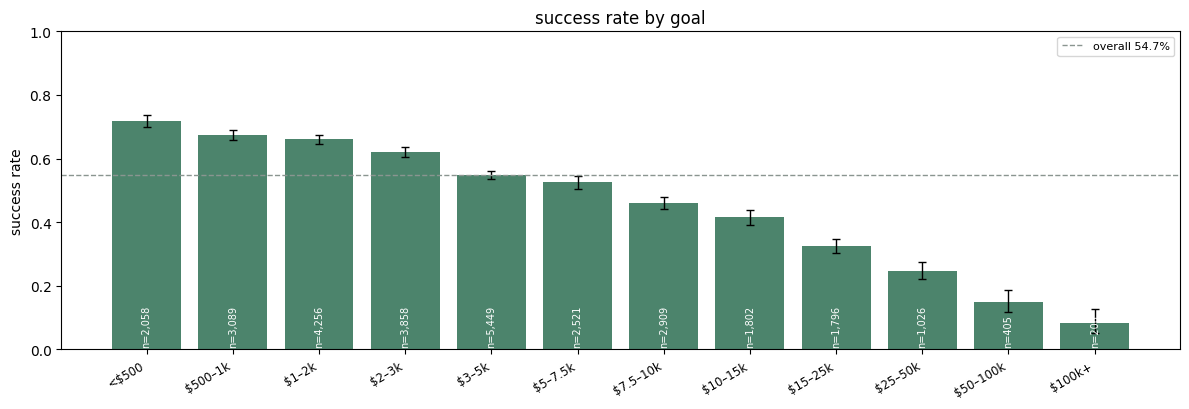

In [9]:
bins = [0, 500, 1000, 2000, 3000, 5000, 7500, 10000, 15000, 25000, 50000, 100000, 1e9]
labels = ["<$500", "$500–1k", "$1–2k", "$2–3k", "$3–5k", "$5–7.5k", "$7.5–10k", "$10–15k", "$15–25k", "$25–50k", "$50–100k", "$100k+"]
g_goal = rate_table(train_df, pd.cut(train_df["goal"], bins, labels=labels))
fig, ax = plt.subplots(figsize=(12, 4.2))
rate_plot(ax, g_goal, "success rate by goal", rotate=30)
plt.tight_layout()
g_goal[["n", "rate", "ci_lo", "ci_hi", "vs_base"]].round(3)

There seems to be a small correlation between success rate and duration of the campaign. With the campaign being more likely to be successful if it lasted less. We can also see that we have two commonly chosen durations, though these might just be a preference for those particular numbers rather than any additional information.

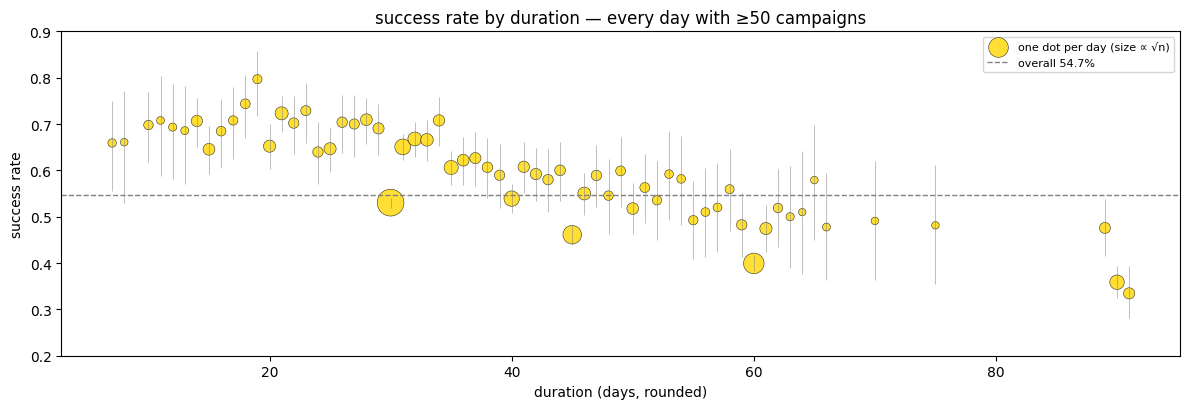

In [10]:
by_day = rate_table(train_df, train_df["duration"].round().astype(int))

fig, ax = plt.subplots(figsize=(12, 4.2))
ax.scatter(by_day.index, by_day["rate"], s=np.sqrt(by_day["n"]) * 4, color='gold', alpha=0.8,
           edgecolor="k", lw=0.4, label="one dot per day (size ∝ √n)")
ax.errorbar(by_day.index, by_day["rate"], yerr=[by_day["rate"] - by_day["ci_lo"], by_day["ci_hi"] - by_day["rate"]],
            fmt="none", ecolor='grey', lw=0.6, alpha=0.6)
ax.axhline(by_day.attrs["base"], color='grey', ls="--", lw=1, label=f"overall {by_day.attrs['base']:.1%}")

ax.set_xlabel("duration (days, rounded)"); ax.set_ylabel("success rate"); ax.set_ylim(0.2, 0.9)
ax.set_title("success rate by duration — every day with ≥50 campaigns"); ax.legend(fontsize=8)
plt.tight_layout()

# Success by Category
Overall there is a big difference between the success of different categories, however this might also be because there is a small overlap between the msot popular categories and the most succesful.

the 2 largest categories cover 53.0% of the training set; the 6 smallest cover 12.3%


,n,share,cumulative share,n subcategories,median goal
category,,,,,
Film &amp; Video,8555,0.291,0.291,6,5000.0
Music,7022,0.239,0.530,11,3000.0
Publishing,2866,0.098,0.628,8,3500.0
Art,2602,0.089,0.716,9,2700.0
Theater,1608,0.055,0.771,1,2500.0
Design,1084,0.037,0.808,4,6000.0
Games,1054,0.036,0.844,4,5000.0
Photography,979,0.033,0.877,1,3000.0
Food,918,0.031,0.909,1,7500.0


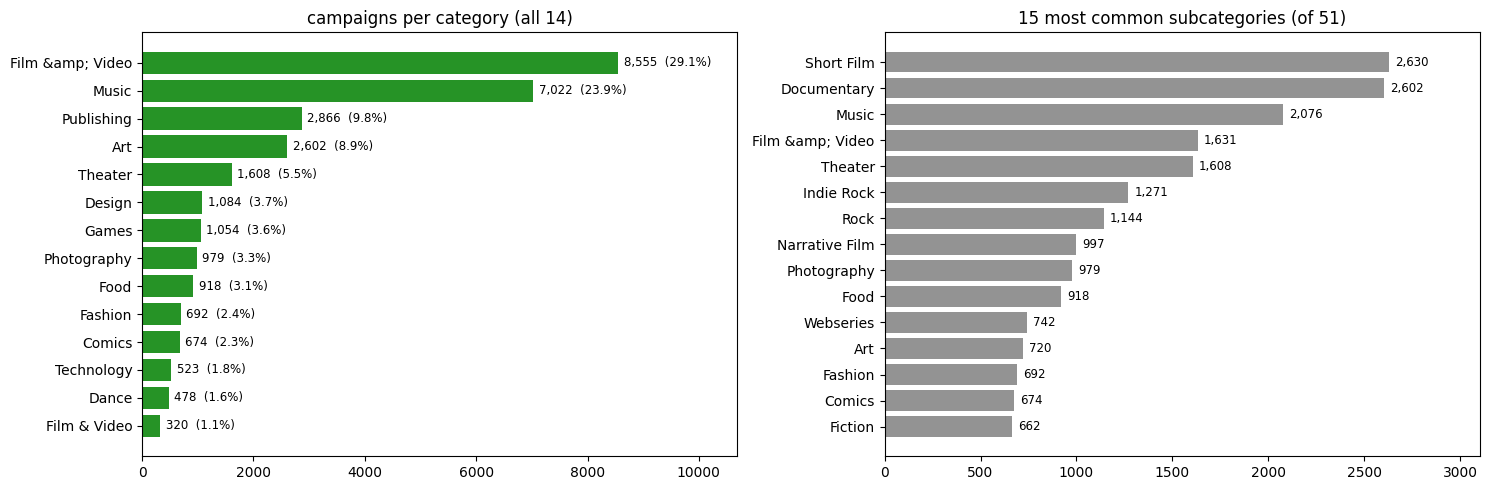

In [11]:
cat_n = train_df["category"].value_counts()
sub_n = train_df["subcategory"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ax = axes[0]
ax.barh(cat_n.index[::-1], cat_n.values[::-1], color='green', alpha=0.85)
for i, v in enumerate(cat_n.values[::-1]):
    ax.text(v + cat_n.max() * 0.012, i, f"{v:,}  ({v/len(train_df):.1%})", va="center", fontsize=8.5)
ax.set_xlim(0, cat_n.max() * 1.25)
ax.set_title(f"campaigns per category (all {len(cat_n)})")

ax = axes[1]
topk = sub_n.head(15)
ax.barh(topk.index[::-1], topk.values[::-1], color='grey', alpha=0.85)
for i, v in enumerate(topk.values[::-1]):
    ax.text(v + topk.max() * 0.012, i, f"{v:,}", va="center", fontsize=8.5)
ax.set_xlim(0, topk.max() * 1.18)
ax.set_title(f"15 most common subcategories (of {len(sub_n)})")
plt.tight_layout()

summary = pd.DataFrame({"n": cat_n, "share": cat_n / len(train_df)})
summary["cumulative share"] = summary["share"].cumsum()
summary["n subcategories"] = train_df.groupby("category")["subcategory"].nunique()
summary["median goal"] = train_df.groupby("category")["goal"].median()
print(f"the 2 largest categories cover {summary['share'].head(2).sum():.1%} of the training set; "
      f"the 6 smallest cover {summary['share'].tail(6).sum():.1%}")
summary.round(3)

,n,rate,vs_base,median goal
category,,,,
Dance,478,0.759,0.212,2500.0
Theater,1608,0.705,0.158,2500.0
Music,7022,0.674,0.126,3000.0
Art,2602,0.578,0.031,2700.0
Film & Video,320,0.550,0.003,5000.0
Comics,674,0.539,-0.009,3000.0
Food,918,0.509,-0.039,7500.0
Film &amp; Video,8555,0.507,-0.040,5000.0
Design,1084,0.465,-0.082,6000.0


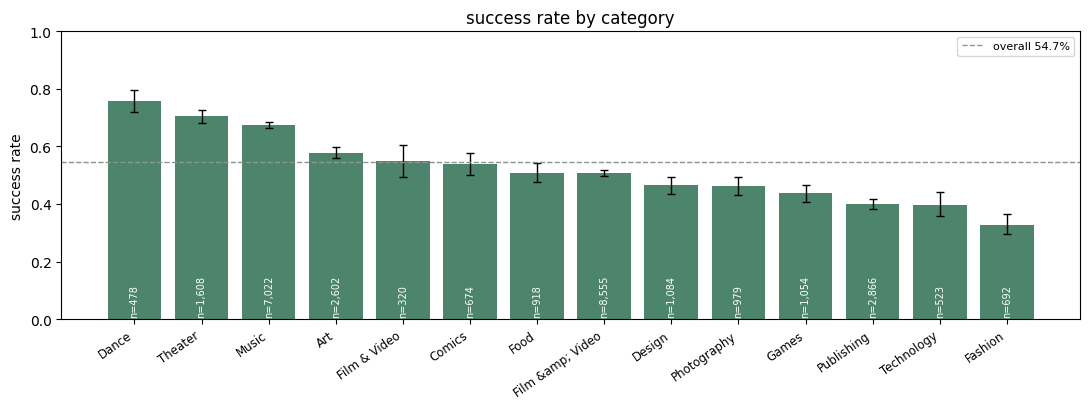

In [12]:
g_cat = rate_table(train_df, "category").sort_values("rate", ascending=False)
g_cat["median goal"] = train_df.groupby("category")["goal"].median()
fig, ax = plt.subplots(figsize=(11, 4.2))
rate_plot(ax, g_cat, "success rate by category", rotate=35)
plt.tight_layout()
g_cat[["n", "rate", "vs_base", "median goal"]].round(3)

,n,rate,category,median goal
subcategory,,,,
Dance,478,0.759,Dance,2500.0
Country &amp; Folk,524,0.758,Music,3300.0
Indie Rock,1271,0.744,Music,2500.0
Classical Music,302,0.732,Music,3000.0
Country & Folk,160,0.731,Music,3000.0
Jazz,299,0.709,Music,4000.0
Theater,1608,0.705,Theater,2500.0
Rock,1144,0.676,Music,2500.0
Public Art,339,0.673,Art,3000.0


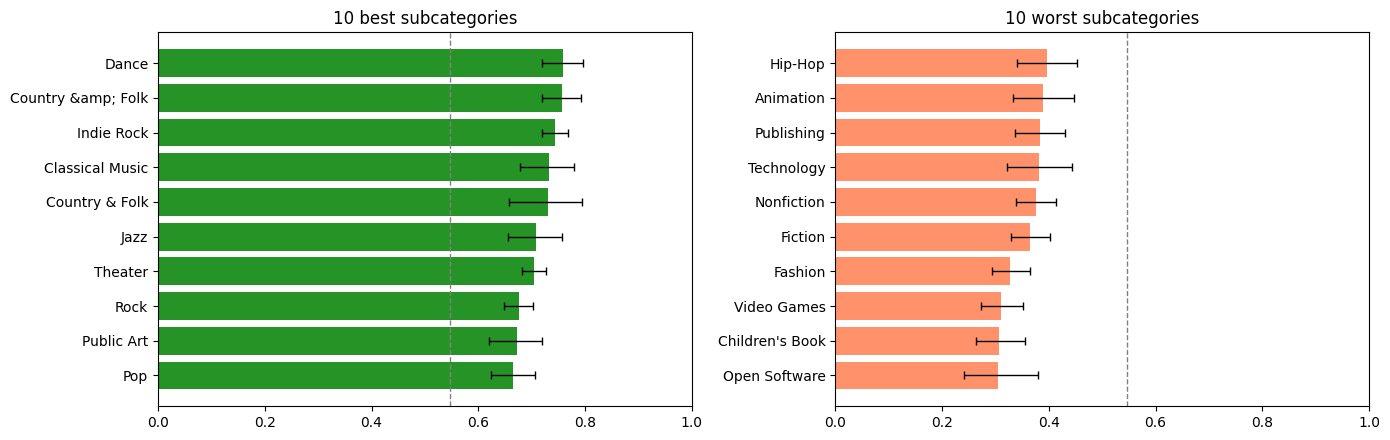

In [13]:
g_sub = rate_table(train_df, "subcategory", min_n=150)
g_sub["category"] = train_df.groupby("subcategory")["category"].agg(lambda s: s.mode()[0])
g_sub["median goal"] = train_df.groupby("subcategory")["goal"].median()
top, bot = g_sub.nlargest(10, "rate"), g_sub.nsmallest(10, "rate")
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, g, t, col in [(axes[0], top.iloc[::-1], "10 best subcategories", 'green'), (axes[1], bot, "10 worst subcategories", 'coral')]:
    ax.barh(g.index, g["rate"], color=col, alpha=0.85)
    ax.errorbar(g["rate"], range(len(g)), xerr=[g["rate"] - g["ci_lo"], g["ci_hi"] - g["rate"]], fmt="none", ecolor="k", capsize=3, lw=1)
    ax.axvline(train_df["target"].mean(), color='grey', ls="--", lw=1); ax.set_xlim(0, 1); ax.set_title(t)
plt.tight_layout()
pd.concat([top, bot])[["n", "rate", "category", "median goal"]].round(3)

# Reward Tiers
There is a small correlation between geometric step, average multiplier between one tier and the next, and success, whether the reward tiers actually contribute to overall success would be difficult to determine since we would probably have to observe behavior over time, and how reaching a reward, or being close to one affect the donations received.

In [14]:
samples = train_df.loc[
    train_df["reward levels"].notna(),
    ["levels", "reward levels"]
].sample(20, random_state=42)

for idx, row in samples.iterrows():
    print("=" * 80)
    print("index:", idx)
    print("levels:", row["levels"])
    print("repr:", repr(row["reward levels"]))

index: 12482
levels: 7
repr: '$10,$25,$50,$100,$350,$1,000,$2,000'
index: 32380
levels: 8
repr: '$5,$10,$25,$35,$40,$50,$100,$500'
index: 12252
levels: 8
repr: '$5,$15,$25,$50,$100,$250,$500,$1,000'
index: 24977
levels: 9
repr: '$5,$10,$25,$50,$100,$200,$250,$500,$1,500'
index: 41685
levels: 12
repr: '$5,$15,$25,$35,$50,$75,$100,$150,$200,$300,$400,$500'
index: 44412
levels: 12
repr: '$6,$17,$25,$50,$125,$200,$407,$800,$2,250,$2,250,$3,500,$3,500'
index: 31056
levels: 5
repr: '$15,$25,$50,$100,$500'
index: 3353
levels: 10
repr: '$1,$10,$25,$50,$100,$250,$500,$1,000,$2,500,$5,000'
index: 6895
levels: 11
repr: '$1,$5,$10,$25,$60,$120,$198,$500,$1,000,$2,000,$4,000'
index: 18491
levels: 5
repr: '$10,$25,$50,$100,$250'
index: 2365
levels: 8
repr: '$5,$10,$25,$50,$100,$250,$500,$5,000'
index: 39852
levels: 8
repr: '$5,$35,$100,$150,$250,$500,$1,000,$2,500'
index: 37639
levels: 3
repr: '$20,$50,$75'
index: 26031
levels: 10
repr: '$10,$25,$50,$75,$100,$200,$350,$500,$750,$1,000'
index: 31048


In [15]:
mask = train_df["reward levels"].astype(str).str.contains(
    "1,000",
    regex=False
)

for idx, row in train_df.loc[
    mask,
    ["levels", "reward levels"]
].head(20).iterrows():
    print("=" * 80)
    print("index:", idx)
    print("levels:", row["levels"])
    print("repr:", repr(row["reward levels"]))

index: 5060
levels: 7
repr: '$10,$25,$50,$100,$200,$500,$1,000'
index: 47
levels: 3
repr: '$20,$100,$1,000'
index: 40816
levels: 10
repr: '$1,$5,$10,$25,$50,$100,$250,$500,$1,000,$3,500'
index: 8643
levels: 17
repr: '$1,$5,$7,$7,$10,$15,$20,$20,$25,$50,$100,$250,$500,$750,$1,000,$1,500,$2,500'
index: 39542
levels: 11
repr: '$1,$5,$10,$15,$25,$50,$100,$200,$500,$1,000,$3,000'
index: 8454
levels: 8
repr: '$12,$25,$50,$150,$300,$500,$1,000,$1,500'
index: 5135
levels: 8
repr: '$10,$25,$50,$100,$250,$500,$1,000,$2,500'
index: 35051
levels: 9
repr: '$10,$20,$50,$100,$250,$500,$1,000,$2,500,$5,000'
index: 14494
levels: 8
repr: '$1,$50,$99,$200,$300,$500,$1,000,$1,500'
index: 29781
levels: 8
repr: '$5,$25,$50,$100,$300,$500,$750,$1,000'
index: 34066
levels: 8
repr: '$1,$5,$20,$30,$100,$250,$500,$1,000'
index: 12005
levels: 7
repr: '$20,$25,$50,$100,$500,$1,000,$1,500'
index: 34647
levels: 9
repr: '$5,$20,$30,$60,$100,$250,$500,$1,000,$5,000'
index: 7138
levels: 13
repr: '$5,$15,$25,$30,$50,$50

In [16]:
print(train_df.columns.tolist())
print("tier_step" in train_df.columns)

['project id', 'name', 'url', 'category', 'subcategory', 'location', 'goal', 'pledged', 'funded percentage', 'backers', 'funded date', 'levels', 'reward levels', 'updates', 'comments', 'duration', 'target']
False


In [17]:
import re
import numpy as np

def parse_reward_levels(value):
    if pd.isna(value):
        return []

    amounts = re.findall(
        r"\$(\d+(?:,\d{3})*(?:\.\d+)?)",
        str(value)
    )

    return [
        float(amount.replace(",", ""))
        for amount in amounts
    ]

In [18]:
parsed_rewards = train_df["reward levels"].apply(parse_reward_levels)

comparison = pd.DataFrame({
    "levels": train_df["levels"],
    "parsed_levels": parsed_rewards.apply(len),
    "reward levels": train_df["reward levels"]
})

comparison.head(20)

,levels,parsed_levels,reward levels
40825,10,10,"$10,$25,$35,$45,$95,$150,$200,$250,$325,$450"
16576,6,6,"$10,$25,$50,$100,$150,$250"
5060,7,7,"$10,$25,$50,$100,$200,$500,$1,000"
47,3,3,"$20,$100,$1,000"
6455,6,6,"$10,$30,$60,$100,$250,$500"
40816,10,10,"$1,$5,$10,$25,$50,$100,$250,$500,$1,000,$3,500"
8643,17,17,"$1,$5,$7,$7,$10,$15,$20,$20,$25,$50,$100,$250,..."
39542,11,11,"$1,$5,$10,$15,$25,$50,$100,$200,$500,$1,000,$3..."
1286,4,4,"$5,$30,$40,$60"
8454,8,8,"$12,$25,$50,$150,$300,$500,$1,000,$1,500"


In [19]:
print(
    (comparison["levels"] == comparison["parsed_levels"])
    .value_counts()
)

True    29375
Name: count, dtype: int64


In [20]:
def geometric_tier_step(tiers):
    if len(tiers) < 2:
        return np.nan

    first = float(tiers[0])
    last = float(tiers[-1])

    if first <= 0 or last <= 0:
        return np.nan

    return (last / first) ** (1 / (len(tiers) - 1))

In [21]:
train_df["tier_step"] = parsed_rewards.apply(
    geometric_tier_step
)

In [22]:
pd.qcut(
    train_df["tier_step"],
    8,
    duplicates="drop"
).value_counts(sort=False)

tier_step
(0.999, 1.699]     3583
(1.699, 1.919]     3700
(1.919, 2.115]     3846
(2.115, 2.187]     3566
(2.187, 2.43]      3634
(2.43, 2.683]      3225
(2.683, 3.162]     3550
(3.162, 1000.0]    3527
Name: count, dtype: int64

,n,rate,ci_lo,ci_hi,vs_base
tier_step,,,,,
"(0.999, 1.699]",3583,0.679,0.664,0.694,0.132
"(1.699, 1.919]",3700,0.633,0.617,0.648,0.086
"(1.919, 2.115]",3846,0.602,0.586,0.617,0.055
"(2.115, 2.187]",3566,0.599,0.583,0.615,0.052
"(2.187, 2.43]",3634,0.534,0.518,0.551,-0.013
"(2.43, 2.683]",3225,0.510,0.493,0.527,-0.038
"(2.683, 3.162]",3550,0.464,0.448,0.481,-0.083
"(3.162, 1000.0]",3527,0.395,0.379,0.411,-0.152


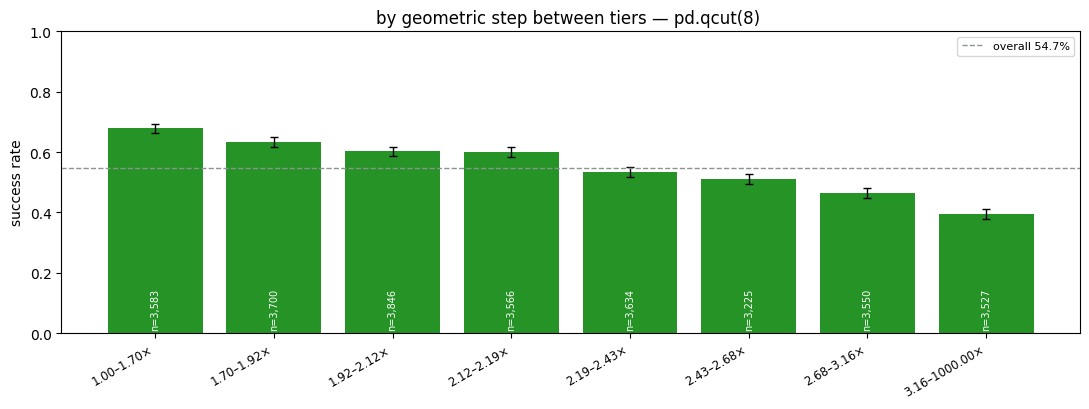

In [23]:
ts = rate_table(train_df, pd.qcut(train_df["tier_step"], 8, duplicates="drop"))
fig, ax = plt.subplots(figsize=(11, 4.2))
rate_plot(ax, ts, "by geometric step between tiers — pd.qcut(8) ", color='green',
          labels=[f"{iv.left:.2f}–{iv.right:.2f}×" for iv in ts.index], rotate=30)
plt.tight_layout()
ts[["n", "rate", "ci_lo", "ci_hi", "vs_base"]].round(3)

# Success rate by state

                  n   rate  vs_base
has_location                       
blank           903  0.481   -0.067
given         28472  0.549    0.002


,n,rate,vs_base
state,,,
FL,956,0.359,-0.189
NV,238,0.374,-0.173
GA,692,0.418,-0.130
NJ,383,0.436,-0.111
AZ,393,0.445,-0.102
OR,810,0.594,0.046
IL,1224,0.603,0.056
LA,309,0.621,0.074
MA,867,0.645,0.097


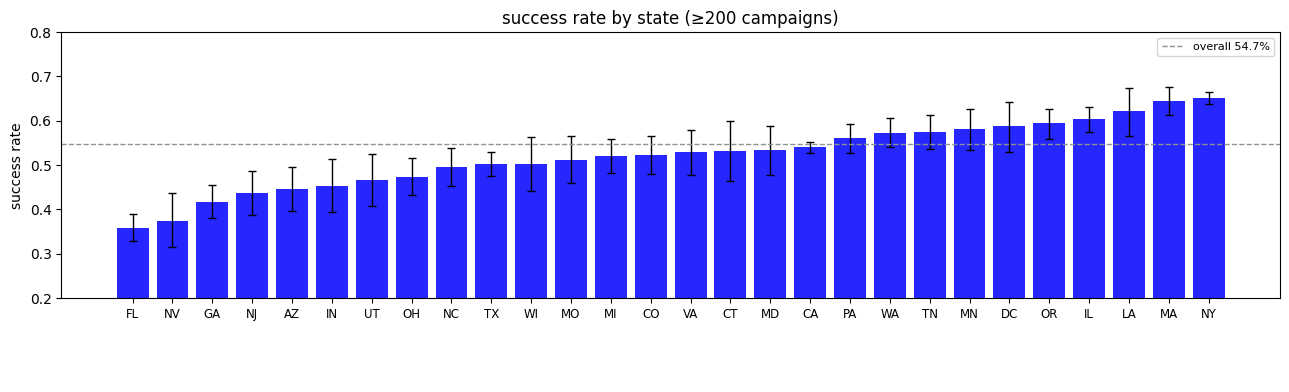

In [24]:
loc = train_df["location"].astype(str)
train_df["state"] = loc.str.extract(r",\s*([A-Z]{2})\s*$")[0]
train_df["has_location"] = train_df["location"].notna().astype(int)
print(rate_table(train_df, "has_location").rename(index={0: "blank", 1: "given"})[["n", "rate", "vs_base"]].round(3))
g_st = rate_table(train_df, "state", min_n=200).sort_values("rate")
fig, ax = plt.subplots(figsize=(13, 4.2))
rate_plot(ax, g_st, "success rate by state (≥200 campaigns)", color='blue', rotate=0)
ax.set_ylim(0.2, 0.8)
plt.tight_layout()
pd.concat([g_st.head(5), g_st.tail(5)])[["n", "rate", "vs_base"]].round(3)

# Examing cross-tabulated heatmaps of category, success rate, target, and duration

As expected, most categories do better with smaller goals; we can also see the earlier chart on duration against success rate supported here, however we can also see the impact on the success rate also depends on the goal for the crowdfounding, with it mattering more for bigger goals than smaller ones when comparing by pct increased or decreased.

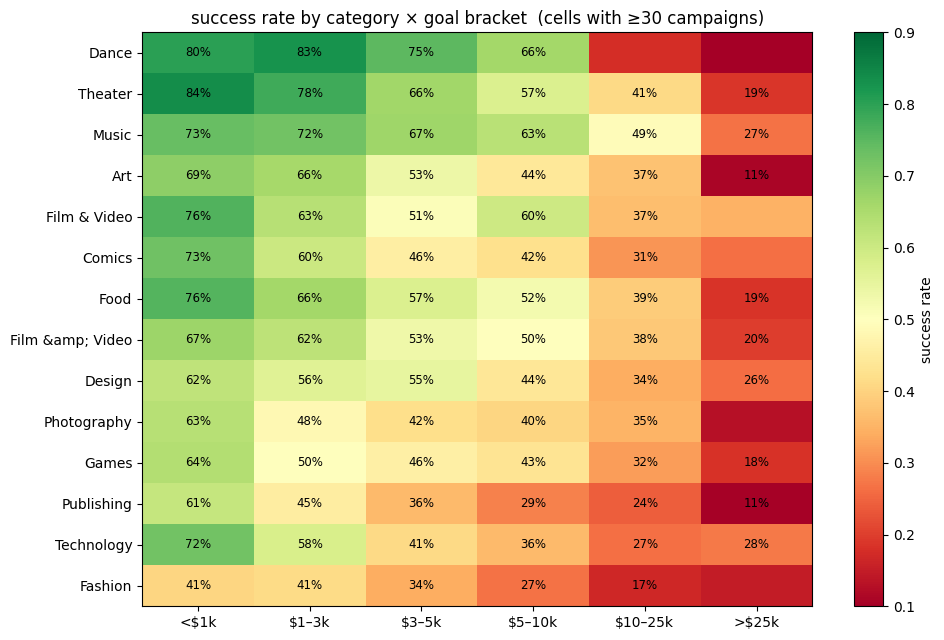

In [25]:
gb = pd.cut(train_df["goal"], [0, 1000, 3000, 5000, 10000, 25000, 1e9], labels=["<$1k", "$1–3k", "$3–5k", "$5–10k", "$10–25k", ">$25k"])
ct = pd.crosstab(train_df["category"], gb, values=train_df["target"], aggfunc="mean")
cn = pd.crosstab(train_df["category"], gb)
ct = ct.loc[g_cat.index]
cn = cn.reindex(index=ct.index, columns=ct.columns, fill_value=0)
fig, ax = plt.subplots(figsize=(10, 6.5))
im = ax.imshow(ct.values, cmap="RdYlGn", vmin=0.1, vmax=0.9, aspect="auto")
ax.set_xticks(range(ct.shape[1])); ax.set_xticklabels(ct.columns)
ax.set_yticks(range(ct.shape[0])); ax.set_yticklabels(ct.index)
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        if cn.iloc[i, j] >= 30:
            ax.text(j, i, f"{ct.iloc[i, j]:.0%}", ha="center", va="center", fontsize=8.5)
plt.colorbar(im, ax=ax, label="success rate"); ax.grid(False)
ax.set_title("success rate by category × goal bracket  (cells with ≥30 campaigns)")
plt.tight_layout()

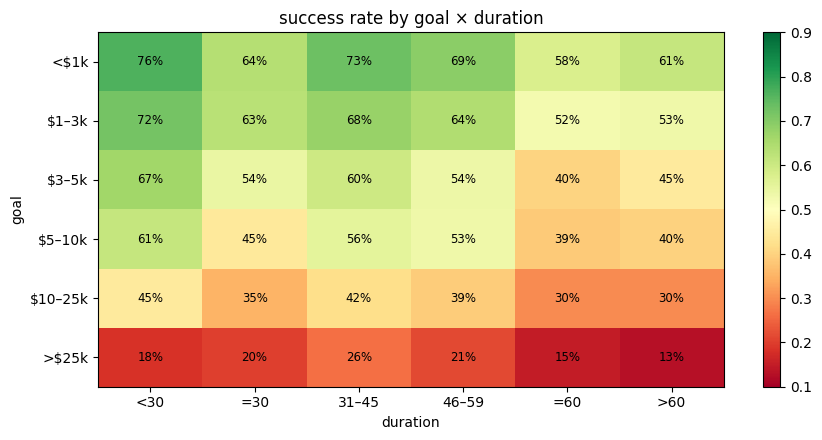

In [26]:
db = pd.cut(train_df["duration"], [0, 29.5, 30.5, 45, 59.5, 60.5, 100], labels=["<30", "=30", "31–45", "46–59", "=60", ">60"])
ct2 = pd.crosstab(gb, db, values=train_df["target"], aggfunc="mean")
cn2 = pd.crosstab(gb, db)
fig, ax = plt.subplots(figsize=(9, 4.5))
im = ax.imshow(ct2.values, cmap="RdYlGn", vmin=0.1, vmax=0.9, aspect="auto")
ax.set_xticks(range(ct2.shape[1])); ax.set_xticklabels(ct2.columns); ax.set_xlabel("duration")
ax.set_yticks(range(ct2.shape[0])); ax.set_yticklabels(ct2.index); ax.set_ylabel("goal")
for i in range(ct2.shape[0]):
    for j in range(ct2.shape[1]):
        if cn2.iloc[i, j] >= 30:
            ax.text(j, i, f"{ct2.iloc[i, j]:.0%}", ha="center", va="center", fontsize=8.5)
plt.colorbar(im, ax=ax); ax.grid(False); ax.set_title("success rate by goal × duration")
plt.tight_layout()

# Distribution of the target Variable 

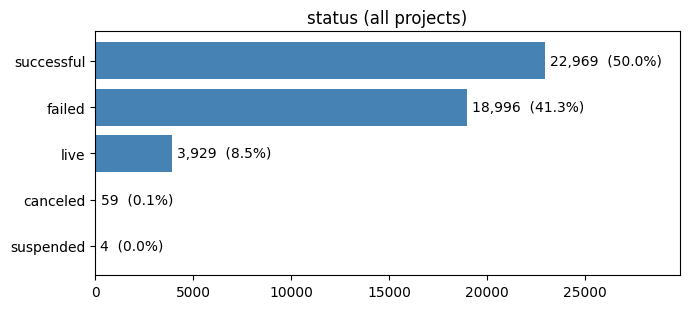

In [27]:
order = ["successful", "failed", "live", "canceled", "suspended"]
st = df["status"].value_counts().reindex(order, fill_value=0)

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.barh(st.index[::-1], st.values[::-1], color="steelblue")
for i, v in enumerate(st.values[::-1]):
    ax.text(v + st.max() * 0.01, i, f"{v:,}  ({v/len(df):.1%})", va="center")
ax.set_xlim(0, st.max() * 1.3)
ax.set_title("status (all projects)")
plt.tight_layout()

# Duplicate Project Audit

In [28]:
print("Exact duplicate rows:", df.duplicated().sum())
print("Duplicate project IDs:", df["project id"].duplicated().sum())

duplicate_projects = (
    df[df["project id"].duplicated(keep=False)]
    .sort_values("project id")
)

duplicate_projects.head(20)

Exact duplicate rows: 89
Duplicate project IDs: 142


,project id,name,url,category,subcategory,location,status,goal,pledged,funded percentage,backers,funded date,levels,reward levels,updates,comments,duration
45651,2140333236,Imagined Family Heirlooms: An Archive of Inher...,http://www.kickstarter.com/projects/andersonst...,Photography,Photography,"Little Rock, AR",successful,5800.0,8521.0,1.469138,110,"Fri, 29 Jul 2011 00:53:53 -0000",16,"$10,$20,$35,$50,$75,$100,$150,$200,$225,$300,$...",5,4,67.00
45652,2140333236,Imagined Family Heirlooms: An Archive of Inher...,http://www.kickstarter.com/projects/andersonst...,Photography,Photography,"Little Rock, AR",successful,5800.0,8521.0,1.469138,110,"Fri, 29 Jul 2011 00:53:53 -0000",16,"$10,$20,$35,$50,$75,$100,$150,$200,$225,$300,$...",5,4,67.00
45653,2140344109,Help Fund Thana Alexa's Debut Album &quot;Ode ...,http://www.kickstarter.com/projects/1024906052...,Music,Jazz,"New York, NY",successful,15000.0,16678.0,1.111867,142,"Sun, 20 May 2012 20:36:57 -0000",16,"$1,$5,$10,$15,$25,$50,$75,$100,$200,$250,$300,...",5,2,32.00
45654,2140344109,Help Fund Thana Alexa's Debut Album &quot;Ode ...,http://www.kickstarter.com/projects/1024906052...,Music,Jazz,"New York, NY",successful,15000.0,16678.0,1.111867,142,"Sun, 20 May 2012 20:36:57 -0000",16,"$1,$5,$10,$15,$25,$50,$75,$100,$200,$250,$300,...",5,2,32.00
45655,2140513451,The Cookie Chew - Changing the Way We Eat a Co...,http://www.kickstarter.com/projects/1650956569...,Food,Food,"San Diego, CA",successful,4500.0,5540.0,1.231111,89,"Tue, 24 Aug 2010 04:43:00 -0000",5,"$10,$50,$75,$100,$500",14,17,43.27
45656,2140513451,The Cookie Chew - Changing the Way We Eat a Co...,http://www.kickstarter.com/projects/1650956569...,Food,Food,"San Diego, CA",successful,4500.0,5540.0,1.231111,89,"Tue, 24 Aug 2010 04:43:00 -0000",5,"$10,$50,$75,$100,$500",14,17,43.27
45657,2140547791,Ant Invasion iPhone Game App,http://www.kickstarter.com/projects/antinvasio...,Games,Video Games,"Burlington, NJ",failed,5000.0,0.0,0.000000,0,"Mon, 19 Sep 2011 19:08:43 -0000",7,"$1,$5,$10,$20,$50,$100,$500",1,0,45.00
45658,2140547791,Ant Invasion iPhone Game App,http://www.kickstarter.com/projects/antinvasio...,Games,Video Games,"Burlington, NJ",failed,5000.0,0.0,0.000000,0,"Mon, 19 Sep 2011 19:08:43 -0000",7,"$1,$5,$10,$20,$50,$100,$500",1,0,45.00
45659,2140567876,THE HUAORANI: Savages of Oriente/Protectors of...,http://www.kickstarter.com/projects/34840787/t...,Film &amp; Video,Documentary,"Astoria, NY",successful,5000.0,5730.0,1.146000,85,"Tue, 05 Jul 2011 03:59:00 -0000",11,"$10,$25,$30,$50,$75,$100,$250,$500,$1,000,$2,0...",9,4,48.34
45660,2140567876,THE HUAORANI: Savages of Oriente/Protectors of...,http://www.kickstarter.com/projects/34840787/t...,Film & Video,Documentary,"Astoria, NY",successful,5000.0,5730.0,1.146000,85,"Tue, 05 Jul 2011 03:59:00 -0000",11,"$10,$25,$30,$50,$75,$100,$250,$500,$1,000,$2,0...",9,4,48.34


In [29]:
duplicate_summary = (
    duplicate_projects
    .groupby("project id")
    .agg(
        rows=("project id", "size"),
        names=("name", "nunique"),
        urls=("url", "nunique"),
        statuses=("status", "nunique"),
    )
)

duplicate_summary.sort_values("rows", ascending=False).head(20)

,rows,names,urls,statuses
project id,,,,
2140333236,2,1,1,1
2144527455,2,1,1,1
2144010374,2,1,1,1
2144102391,2,1,1,1
2144175941,2,1,1,1
2144203763,2,1,1,1
2144285332,2,1,1,1
2144289603,2,1,1,1
2144577345,2,1,1,1


In [30]:
duplicate_projects = df[
    df["project id"].duplicated(keep=False)
].sort_values("project id")

duplicate_conflicts = (
    duplicate_projects
    .groupby("project id")
    .nunique()
)

print("Exact duplicate rows beyond first:", df.duplicated().sum())
print("Repeated project-ID rows beyond first:", df["project id"].duplicated().sum())
print("Distinct project IDs involved in duplicates:",
      duplicate_projects["project id"].nunique())
print("Project IDs with conflicting values:",
      (duplicate_conflicts > 1).any(axis=1).sum())

Exact duplicate rows beyond first: 89
Repeated project-ID rows beyond first: 142
Distinct project IDs involved in duplicates: 142
Project IDs with conflicting values: 53


In [31]:
duplicate_conflicts = (
    duplicate_projects
    .groupby("project id")
    .nunique()
)

duplicate_conflicts[
    (duplicate_conflicts > 1).any(axis=1)
]

,name,url,category,subcategory,location,status,goal,pledged,funded percentage,backers,funded date,levels,reward levels,updates,comments,duration
project id,,,,,,,,,,,,,,,,
2140567876,1,1,2,1,1,1,1,1,1,1,1,1,1,1,1,1
2140605581,1,1,2,1,1,1,1,1,1,1,1,1,1,1,1,1
2140705180,1,1,2,1,1,1,1,1,1,1,1,1,1,1,1,1
2140923479,1,1,2,1,1,1,1,1,1,1,1,1,1,1,1,1
2141125937,1,1,2,1,1,1,1,1,1,1,1,1,1,1,1,1
2141171379,1,1,2,1,1,1,1,1,1,1,1,1,1,1,1,1
2141248770,1,1,2,1,1,1,1,1,1,1,1,1,1,1,1,1
2141366388,1,1,2,1,1,1,1,1,1,1,1,1,1,1,1,1
2141525347,1,1,2,1,1,1,1,1,1,1,1,1,1,1,1,1


### Duplicate Project Findings

The raw dataset contains repeated project IDs. There are 89 exact duplicate
rows and 142 duplicate project-ID occurrences overall.

Among rows sharing the same project ID, all columns are identical except
`category` and `subcategory`, which can contain up to two distinct values.
EDA also identified HTML-encoded variants such as `Film &amp; Video` /
`Film & Video` and `Country &amp; Folk` / `Country & Folk`.

This suggests that some apparent duplicate conflicts may result from
inconsistent HTML encoding rather than genuinely different project records.

In `02_clean_data.ipynb`, categorical/text normalization should therefore be
performed before the final duplicate-resolution step. Duplicate project IDs
should then be revalidated before records are removed.

# EDA Summary, Interpretation, and Handoff to Data Cleaning

This notebook explored the Kickstarter dataset with emphasis on the binary
campaign-success prediction problem. The analysis examined dataset structure,
missing values, numerical distributions, campaign goals, duration, category and
subcategory behavior, reward-tier structure, geographic patterns, interactions
between features, target distribution, and duplicate projects.

The EDA also uncovered several data-quality and reproducibility issues that
should be addressed before preprocessing and modeling.


## 1. Dataset and modeling scope

The raw dataset contains **45,957 campaigns** and 17 original columns.

For target-focused EDA, the shared `get_data_split()` utility restricts the
dataset to campaigns whose status is either:

- `successful`
- `failed`

It then creates:

- `target = True` for successful campaigns
- `target = False` for failed campaigns

and performs a stratified train/test split using `random_state=42`.

The exploratory training set contains **29,375 rows**.

This distinction is important: most success-rate analyses in this notebook
describe the subset of **settled successful/failed campaigns**, not every row in
the raw dataset. The raw dataset additionally contains statuses such as `live`,
`canceled`, and `suspended`.

The training-set success rate is approximately **54.8%**, so the settled
successful/failed target is not severely imbalanced.

### Interpretation

Using the training split for target-aware EDA is useful because it avoids using
the held-out test set to make exploratory modeling decisions.

However, duplicate project IDs were discovered later in the EDA. Therefore,
the final modeling workflow should regenerate the train/test split **after
deterministic cleaning and duplicate resolution** so that the same underlying
project cannot potentially appear on both sides of the final split.

## 2. Missing values and dataset completeness

Within the exploratory training set:

- `location` has **903 missing values**, approximately **3.07%**
- `reward levels` has **40 missing values**, approximately **0.14%**
- the other analyzed columns contain no missing values

### Location

Missing locations appear to represent genuinely unavailable geographic
information rather than something that can safely be inferred.

Campaigns with a provided location had an observed success rate of
approximately **54.9%**, while campaigns without a location had an observed
success rate of approximately **48.1%**.

This difference may indicate that missingness itself contains information, but
it should not be interpreted causally.

### Cleaning implication

Missing locations should **not** be replaced with the most common city or state.
Doing so would fabricate geographic information.

The raw missing value should be preserved during deterministic cleaning. A
missing-location indicator or an `"Unknown"` category can be considered later
during preprocessing if useful.


## 3. Goal distribution

Campaign goals have a very wide range and a strongly **right-skewed,
long-tailed distribution**.

In the training set:

- median goal is approximately **$4,000**
- mean goal is approximately **$9,455**
- maximum observed goal is **$3.5 million**

The mean being substantially larger than the median is another indication of
the strong right tail.

The visualizations also show that many campaigns use common rounded goal
amounts.

### Goal and campaign success

Success rate declines strongly as campaign goal increases.

Observed success rates by goal range include approximately:

| Goal range | Success rate |
| --- | ---: |
| `< $500` | 71.9% |
| `$500–1k` | 67.4% |
| `$1–2k` | 66.1% |
| `$2–3k` | 62.2% |
| `$3–5k` | 54.8% |
| `$5–7.5k` | 52.5% |
| `$7.5–10k` | 46.0% |
| `$10–15k` | 41.5% |
| `$15–25k` | 32.5% |
| `$25–50k` | 24.7% |
| `$50–100k` | 14.8% |
| `$100k+` | 8.3% |

### Interpretation

`goal` appears to be one of the strongest potentially useful launch-time
predictors explored in this notebook.

The relationship is descriptive rather than causal: campaigns with large goals
may differ systematically from campaigns with small goals in category, scope,
creator experience, or other characteristics.

### Cleaning and preprocessing implication

Large goals should **not automatically be deleted as outliers** simply because
they are unusual.

In `02_clean_data.ipynb`, goal values should instead be checked for impossible
or invalid values.

The skew itself is better handled later through transformations such as
`log1p(goal)` if appropriate for the selected model.


## 4. Campaign duration

Campaign duration shows a weaker but visible relationship with success.

Shorter campaigns generally appear more likely to succeed than longer
campaigns. The distribution also contains especially common duration choices,
suggesting that creators frequently select certain conventional campaign
lengths.

The training data ranges from approximately:

- **1 day**
- to **91.96 days**

### Interpretation

Duration may contain useful predictive information, but the observed
relationship should not be interpreted as evidence that shortening a campaign
will itself cause success.

Duration may interact with goal amount, campaign category, project complexity,
or creator strategy.

### Cleaning implication

Duration should be checked for impossible values, but unusual valid durations
should not be arbitrarily clipped or removed.


## 5. Category distribution

The dataset is unevenly distributed across categories.

The two largest categories account for approximately **53% of the training
set**:

- `Film &amp; Video`: 8,555 campaigns, approximately 29.1%
- `Music`: 7,022 campaigns, approximately 23.9%

The six smallest categories together account for approximately **12.3%** of
the training set.

### Important data-quality finding

The category analysis revealed that semantically identical categories are
stored using different HTML encodings.

For example:

- `Film &amp; Video`
- `Film & Video`

appear as separate categories.

This means the apparent 14-category structure contains at least one artificial
split caused by inconsistent string encoding.

### Interpretation

Category is potentially useful because observed success rates differ
substantially between categories.

Examples from the current, uncleaned training data include:

- Dance: approximately 75.9%
- Theater: approximately 70.5%
- Music: approximately 67.4%
- Art: approximately 57.8%
- Fashion: approximately 32.8%
- Technology: approximately 39.8%
- Publishing: approximately 40.0%

However, these values should be interpreted cautiously.

First, HTML-encoded duplicates currently split some categories into multiple
labels.

Second, categories differ in typical goal size, project type, and other
characteristics. A higher category-level success rate does not imply that
category itself causes campaign success.

### Cleaning implication

HTML entities should be decoded **before final categorical analysis,
deduplication, encoding, or modeling**.


## 6. Subcategory distribution and success

Subcategory analysis reveals even more variation in observed success rates.

Among subcategories with sufficient sample size, high observed success rates
include approximately:

- Dance: 75.9%
- `Country &amp; Folk`: 75.8%
- Indie Rock: 74.4%
- Classical Music: 73.2%
- `Country & Folk`: 73.1%
- Jazz: 70.9%
- Theater: 70.5%

Lower observed success rates include approximately:

- Open Software: 30.5%
- Children's Book: 30.7%
- Video Games: 31.1%
- Fashion: 32.8%
- Fiction: 36.4%
- Nonfiction: 37.5%

### Important data-quality finding

The same HTML-encoding problem found in `category` also appears in
`subcategory`.

For example:

- `Country &amp; Folk`
- `Country & Folk`

are treated as two separate values even though they represent the same
subcategory.

### Interpretation

Subcategory may provide more detailed predictive information than the broader
category field, but its values should be normalized before any encoding or
modeling.

Success-rate differences are again descriptive and may partly reflect
differences in goal size, audience, campaign type, and sample size.

## 7. HTML entities and text consistency

EDA identified HTML entities in multiple human-readable fields.

Examples include:

- `Film &amp; Video`
- `Country &amp; Folk`
- `&quot;Chased Resignation&quot;`

This indicates that HTML encoding is not limited to a single column.

### Cleaning implication

`02_clean_data.ipynb` should perform deterministic HTML decoding on appropriate
human-readable text fields such as:

- `name`
- `category`
- `subcategory`
- possibly `location` if encoded values are discovered there

This should be done before duplicate resolution because some records that
currently look different may become identical after decoding.

URLs should be treated separately rather than blindly applying every text
normalization rule to them.

## 8. Reward-level format investigation

The `reward levels` column contains strings representing Kickstarter reward
amounts.

Examples include values such as:

`$10,$25,$50,$100,$350,$1,000,$2,000`

A naive comma-based parser would be incorrect because commas serve two
different purposes:

1. separating reward tiers
2. representing thousands inside an amount such as `$1,000`

The reward-level strings were therefore inspected directly using `repr()` and
a parser was created that extracts dollar-prefixed monetary values.

### Parser validation

The parsed number of reward amounts was compared with the existing `levels`
column.

The result was:

`True    29375`

meaning that the parser-derived tier count matches the provided `levels`
column for **every row in the exploratory training set**.

This is a strong internal validation of the parsing method.

### Missing reward-level interpretation

`reward levels` contains 40 missing values in the training split.

Because the parser returns zero levels for missing reward strings and the
parsed count still matches the existing `levels` column for every row, these
missing strings are consistent with campaigns that have **zero reward tiers**
rather than unexplained parser failures.

This relationship should still be verified on the complete raw dataset in
`02_clean_data.ipynb` before applying the interpretation globally.


## 9. Reconstructing the missing `tier_step` feature

The original EDA referenced:

`train_df["tier_step"]`

but the feature was not created anywhere in the committed notebook or shared
utility files.

Repository and Git-history inspection confirmed that the original target-focused
EDA commit used `tier_step` without committing the feature-construction code.

To make the notebook reproducible, the reward-level format was investigated and
the feature was reconstructed.

`tier_step` represents the geometric average multiplicative distance between
reward tiers.

For positive tiers:

`t1, t2, ..., tn`

the geometric mean of the adjacent ratios is:

`geometric_mean(t2/t1, t3/t2, ..., tn/t(n-1))`

which algebraically simplifies to:

`(tn / t1) ** (1 / (n - 1))`

The reconstructed implementation therefore uses:

`(last_tier / first_tier) ** (1 / (number_of_tiers - 1))`

for campaigns with at least two positive tiers.

### Reproducibility validation

The reconstructed `tier_step` produces the **exact same quantile boundaries,
group counts, success rates, confidence intervals, and differences from the
overall success rate as the original saved notebook output**.

The reproduced results are:

| `tier_step` interval | n | Success rate |
| --- | ---: | ---: |
| `(0.999, 1.699]` | 3,583 | 67.9% |
| `(1.699, 1.919]` | 3,700 | 63.3% |
| `(1.919, 2.115]` | 3,846 | 60.2% |
| `(2.115, 2.187]` | 3,566 | 59.9% |
| `(2.187, 2.430]` | 3,634 | 53.4% |
| `(2.430, 2.683]` | 3,225 | 51.0% |
| `(2.683, 3.162]` | 3,550 | 46.4% |
| `(3.162, 1000.0]` | 3,527 | 39.5% |

A total of **28,631 training rows** receive a valid `tier_step`. Rows without a
valid value do not contain enough positive reward tiers for this calculation.

### Interpretation

Larger average multiplicative gaps between reward tiers are associated with
lower campaign success in this dataset.

The lowest `tier_step` group has an observed success rate around 67.9%, while
the highest group has an observed success rate around 39.5%.

This does **not** establish that changing reward-tier spacing causes success.
Reward structure may itself reflect campaign type, pricing, creator strategy,
or project scale.

### Pipeline implication

`tier_step` is a **derived feature**, not a raw-data cleaning operation.

The parsing logic should be reproducible, but the final modeling feature belongs
in the feature-engineering stage rather than being treated as an original
cleaned column.


## 10. Location and state analysis

For exploratory purposes, state was extracted from `location` using a
two-uppercase-letter suffix pattern.

Campaigns with a supplied location had an observed success rate of:

- approximately **54.9%** when location was present
- approximately **48.1%** when location was missing

Among states with at least 200 campaigns, examples from the current analysis
include:

Lower observed success rates:

- FL: 35.9%
- NV: 37.4%
- GA: 41.8%
- NJ: 43.6%
- AZ: 44.5%

Higher observed success rates:

- OR: 59.4%
- IL: 60.3%
- LA: 62.1%
- MA: 64.5%
- NY: 65.0%

### Important limitation

The raw location values are not completely standardized.

For example:

`Stevensville, Mt`

uses mixed-case state formatting and would not match the exploratory
two-uppercase-letter extraction rule.

Therefore, the current state-level analysis is incomplete and should be treated
as exploratory rather than as a final geographic representation.

### Interpretation

Geography may contain useful information, but differences between states can
also reflect:

- category composition
- typical campaign goals
- population and market size
- local creative industries
- missingness patterns
- other unobserved factors

The observed state rates should therefore not be interpreted causally.

### Cleaning and feature-engineering implication

`02_clean_data.ipynb` should normalize deterministic formatting issues in
`location` without inventing missing geographic information.

A final `state` feature should be derived only after the location field has been
cleaned and its format understood.

## 11. Category × goal interaction

The category-by-goal heatmap shows that campaign success depends on more than
category alone.

Across many categories, smaller goals generally have higher observed success
rates than larger goals.

### Interpretation

Some of the apparent differences in category success rates may therefore be
partly explained by the typical goal sizes used by campaigns in those
categories.

This is an important reminder that one-variable EDA does not isolate causal
effects.

The corrected heatmap aligns the campaign-count table with the reordered
success-rate table before applying the minimum-sample annotation threshold,
ensuring displayed percentages correspond to the correct categories.


## 12. Goal × duration interaction

The goal-by-duration heatmap supports the earlier individual analyses of goal
and duration.

Goal remains strongly related to success, while the apparent relationship
between duration and success varies across goal ranges.

### Interpretation

Duration should not necessarily be interpreted independently of campaign scale.

This suggests that interaction terms or nonlinear models may eventually capture
useful structure involving:

- goal
- duration
- category

Such modeling decisions belong in later feature engineering/model comparison
rather than deterministic cleaning.

## 13. Target/status distribution

The raw dataset contains multiple campaign statuses, including:

- successful
- failed
- live
- canceled
- suspended

The binary prediction target used in target-focused EDA intentionally includes
only settled campaigns classified as `successful` or `failed`.

### Interpretation

`live`, `canceled`, and `suspended` campaigns do not have the same meaning as a
completed successful/failed outcome and should not automatically be assigned to
the binary target.

The definition of the modeling population should remain explicit throughout
the project.

## 14. Numerical values and extreme observations

The training data contains several numerically extreme values.

Observed maxima include approximately:

- `goal`: $3.5 million
- `pledged`: more than $10 million
- `funded percentage`: 10,000
- `backers`: 87,142
- `levels`: 74
- `updates`: 142
- `comments`: 19,311
- `duration`: 91.96 days

The minimum campaign goal is approximately $0.01, and several count variables
have valid zero values.

### Interpretation

An extreme value is not automatically a data error.

Kickstarter campaigns can legitimately vary by several orders of magnitude, so
automatic IQR deletion, percentile trimming, or winsorization during cleaning
could remove valid projects and distort the dataset.

### Cleaning implication

`02_clean_data.ipynb` should first test **validity constraints**, such as:

- `goal > 0`
- `pledged >= 0`
- `funded percentage >= 0`
- `backers >= 0`
- `levels >= 0`
- `updates >= 0`
- `comments >= 0`
- `duration > 0`

Extreme but valid observations should normally be retained.

If a later model is sensitive to skew or scale, transformations should be
handled during preprocessing rather than by deleting valid observations.

An additional consistency check can compare `funded percentage` against the
relationship implied by `pledged / goal`, while allowing for possible rounding
or source-specific conventions.

## 15. Duplicate project audit

EDA found repeated `project id` values in the raw dataset.

The current audit shows:

- **89 exact duplicate rows beyond their first occurrence**
- **142 repeated project-ID rows beyond their first occurrence**

Therefore, repeated project IDs are not all exact duplicate rows.

A column-by-column comparison of records sharing the same project ID found that
all fields are internally consistent except:

- `category`
- `subcategory`

Those two fields can contain up to two different representations for the same
project.

All other compared fields have at most one unique value within the repeated
project IDs.

### Interpretation

This finding is highly consistent with the HTML-encoding issue found elsewhere
in the EDA.

For example, a repeated project could contain one record labeled:

`Film &amp; Video`

and another labeled:

`Film & Video`

while otherwise representing the exact same campaign.

Therefore, some apparent duplicate conflicts may be **representation conflicts**
rather than genuinely different project records.

### Cleaning implication

The cleaning order matters.

Do **not** simply call:

`drop_duplicates("project id")`

at the beginning of cleaning.

Instead:

1. normalize deterministic text inconsistencies;
2. decode HTML entities;
3. re-audit repeated project IDs;
4. determine whether the records become identical;
5. then retain one deterministic record per project where justified.

This avoids arbitrarily choosing between two differently encoded versions of
the same campaign.

Duplicate resolution should occur before the final train/test split.


## 16. Potential information leakage

Some columns describe activity that occurs after a campaign has launched.

Potentially post-launch variables include:

- `pledged`
- `funded percentage`
- `backers`
- `updates`
- `comments`

If the intended model predicts campaign success using information available at
or near launch, these variables could reveal future campaign performance and
produce unrealistically strong model results.

### Interpretation

These columns are still legitimate raw data and can remain in the cleaned
master dataset.

However, cleaning the data and selecting modeling features are different tasks.

The launch-time modeling feature set should exclude information that would not
have been available at the intended prediction time.

The meaning and availability timing of fields such as `funded date` should also
be confirmed before they are used as predictive features.

Identifiers such as:

- `project id`
- `url`

should likewise not be treated as ordinary numerical/categorical predictors.


# Main EDA Conclusions

The strongest broad relationships observed in the exploratory analysis are:

1. **Goal is strongly associated with campaign success.**
   Success declines substantially as requested funding increases.

2. **Category and subcategory matter, but the raw labels contain encoding
   inconsistencies.**
   These must be normalized before final categorical analysis or encoding.

3. **Duration has a smaller relationship with success and appears to interact
   with goal.**

4. **Reward-tier structure contains potentially useful information.**
   The reconstructed `tier_step` feature shows a clear monotonic relationship
   with observed success rate.

5. **Geography may contain useful information**, but location strings must be
   standardized before a reliable state feature is created.

6. **Missing location may itself be informative**, but missing geographic
   values should not be fabricated.

7. **The dataset contains valid-looking extreme numerical observations.**
   They should be validated rather than automatically removed.

8. **Repeated project IDs exist**, and some apparently conflicting duplicates
   differ only in category/subcategory representation.

9. **Several raw variables are likely unavailable at campaign launch**, so
   feature availability must be considered separately from data cleaning.

10. **The reward-tier EDA originally contained a reproducibility gap.**
    The missing `tier_step` calculation was reconstructed and validated against
    the original saved results exactly.


# Reproducibility Work Added During EDA

In addition to the original exploratory analysis, the notebook now contains
several checks that make the analysis reproducible:

- inspection of raw `reward levels` strings;
- explicit handling of thousands separators such as `$1,000`;
- a reusable reward-level parser;
- validation of parsed reward counts against `levels`;
- reconstruction of the previously undefined `tier_step`;
- exact comparison with the original saved reward-tier EDA output;
- a raw-data duplicate project audit;
- column-level comparison of conflicting repeated project IDs;
- correction of row alignment in the category × goal heatmap;
- explicit identification of cleaning decisions that should occur before
  modeling.

These additions turn previously implicit notebook state into reproducible code
that can be rerun from a fresh kernel.


# Handoff to `02_clean_data.ipynb`

`02_clean_data.ipynb` should start again from the **raw shared dataset** rather
than from the mutated `train_df` created during EDA.

The EDA suggests the following cleaning order.

## 1. Load and protect the raw dataset

Load the raw dataset from the shared Google Drive source and create a separate
working copy.

Do not modify the raw source file.

## 2. Record baseline integrity information

Before changing anything, record:

- shape
- column names
- data types
- missing-value counts
- exact duplicate count
- repeated project-ID count
- unique values for important categorical columns

These values provide a before/after audit trail.

## 3. Normalize deterministic text representation

Decode HTML entities in appropriate human-readable text columns.

Examples include:

- `&amp;` → `&`
- `&quot;` → `"`

Normalize deterministic whitespace issues as well.

Do not apply aggressive transformations such as lowercasing every value unless
there is a documented reason to do so.

## 4. Recheck categorical values

After text normalization, inspect:

- `category`
- `subcategory`

Confirm that artificial variants such as:

- `Film &amp; Video` / `Film & Video`
- `Country &amp; Folk` / `Country & Folk`

have merged correctly.

Record categorical cardinality before and after cleaning.

## 5. Re-audit duplicate project IDs

After text normalization, rerun the duplicate audit.

Determine whether previously conflicting records have become completely
identical.

Where repeated rows now represent the same project, retain one deterministic
record per project.

Document the number of records removed and the rule used.

## 6. Re-audit missing values

Recalculate missing-value counts on the full dataset.

For `location`:

- preserve genuine missing values;
- do not infer an unsupported city or state.

For `reward levels`:

- parse the full dataset;
- compare parsed reward counts against `levels`;
- verify whether missing reward strings continue to correspond to zero reward
  tiers.

## 7. Validate numerical columns

Check for impossible values rather than treating magnitude alone as an error.

Validate at minimum:

- `goal`
- `pledged`
- `funded percentage`
- `backers`
- `levels`
- `updates`
- `comments`
- `duration`

Check for:

- negative values where impossible;
- zero values where impossible;
- infinities;
- unexpected non-numeric values;
- obvious internal inconsistencies.

Retain unusual but valid values.

## 8. Validate dates

Parse `funded date` reproducibly and identify any values that fail conversion.

The semantic meaning and prediction-time availability of the field should be
confirmed separately before modeling.

## 9. Normalize location conservatively

Investigate inconsistent location/state formatting such as:

`Stevensville, Mt`

Normalize obvious formatting inconsistencies without inventing missing
geographic information.

Do not rely on the exploratory uppercase-only state regex as the final location
cleaning strategy.

## 10. Validate the cleaned dataset

After cleaning, verify:

- final shape;
- unique project IDs;
- no unresolved normalization-equivalent duplicates;
- expected categorical values;
- missing-value counts;
- numerical validity constraints;
- date parsing;
- schema consistency.

The cleaning notebook should clearly report how many rows were removed or
changed and why.

## 11. Save a separate cleaned dataset

The cleaned output should be written separately under:

`data/Processed-Data/`

The raw dataset should remain unchanged.



# What Should Not Happen in `02_clean_data.ipynb`

The cleaning notebook should focus on deterministic data-quality corrections.

It should **not** yet perform model-dependent preprocessing such as:

- fitting `StandardScaler`;
- fitting statistical imputers;
- one-hot encoding based on learned category sets;
- target encoding;
- feature selection using the label;
- fitting transformations using the full dataset.

These operations must be learned from training data only to prevent leakage.

Likewise, derived modeling features such as:

- `tier_step`
- a final modeled `state`
- `log1p(goal)`
- interaction features

belong more naturally in later preprocessing or feature-engineering stages.


# Final EDA Takeaway

The raw dataset is usable, but it is not yet modeling-ready.

The most important problems are not widespread missing numerical values.
Instead, the major issues discovered through EDA are:

- inconsistent HTML/text representation;
- repeated project IDs;
- incomplete geographic standardization;
- a small amount of semantically meaningful missing data;
- highly skewed but potentially valid numerical values;
- distinction between raw variables and information available at prediction
  time.

The next stage should therefore prioritize **reproducible deterministic
cleaning and dataset integrity**, while preserving valid information for later
preprocessing and feature engineering.